# 6. Nitrogen

Nitrogen has the widest span of oxidation states any element uses
biologically — eight of them, from ammonium at −III to nitrate at +V — and
unlike carbon it has a *gas* sitting in the middle of the range. That one
fact organises the whole nitrogen cycle: every path down from nitrate and
every path up from ammonium runs into N₂, and N₂ is where nitrogen stays.

In [1]:
import warnings

import matplotlib.pyplot as plt

import microbial_thermo as mt
from microbial_thermo.figures import (
    frost_diagram,
    latimer_diagram,
    plot_frost,
    plot_latimer,
    plot_pourbaix,
)

warnings.filterwarnings("ignore", category=UserWarning)

## The ladder, and an honest gap in it

In [2]:
ladder = latimer_diagram("N", pH=7.0)
ladder.to_frame()

,oxidized,reduced,n electrons,E (V),dG (kJ/mol element),half reaction
0,NO3-,NO2-,2.0,0.407201,-78.577787,NO3- + 2 H+ + 2 e- -> NO2- + H2O
1,NO2-,N2(aq),3.0,0.943915,-273.221826,NO2- + 4 H+ + 3 e- -> N2(aq) + 2 H2O
2,N2(aq),NH4+,3.0,-0.246242,71.276182,N2(aq) + 4 H+ + 3 e- -> NH4+


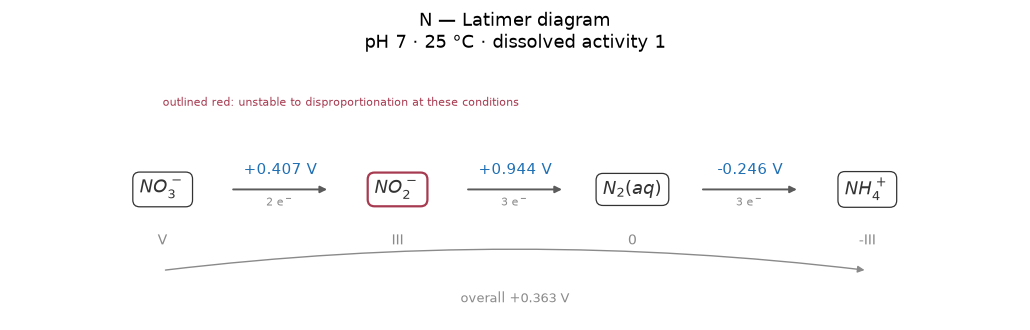

In [3]:
plot_latimer("N", diagram=ladder)
plt.show()

**Nitric oxide and nitrous oxide are missing, and that is a property of the
database rather than of nitrogen.** NO at +II and N₂O at +I are the two
intermediates of denitrification, and neither is in the SUPCRT-lineage
aqueous data this library is built on. The library says so rather than
quietly drawing a ladder that looks complete:

In [4]:
for name in ("NO(aq)", "N2O(aq)", "N2H5+"):
    try:
        mt.resolve(name)
        print(f"{name}: present")
    except Exception as exc:
        print(f"{name}: {type(exc).__name__}")

NO(aq): SpeciesNotFoundError
N2O(aq): SpeciesNotFoundError
N2H5+: SpeciesNotFoundError


So the nitrite → N₂ arrow above is a three-electron step that a real
denitrifier walks in three enzymatic stages through species this diagram
cannot show. The potential is right; the path is not drawn.

## What is stable

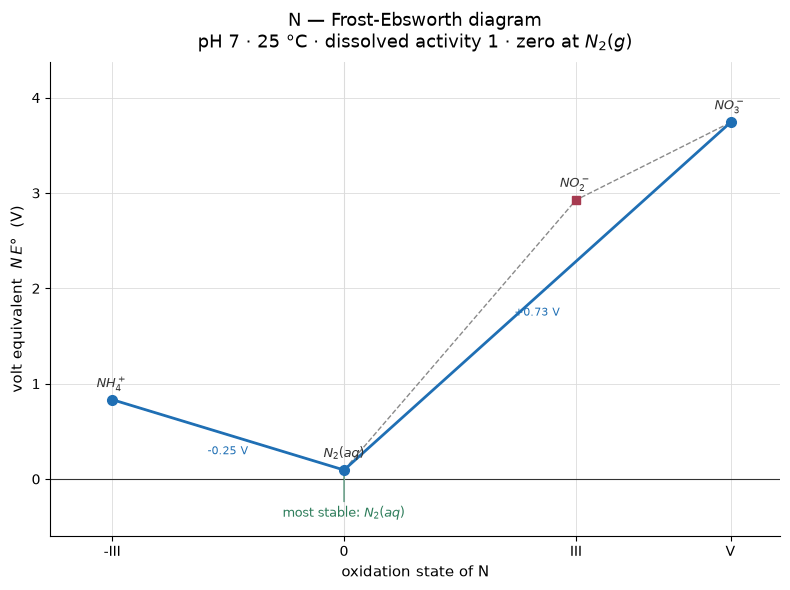

In [5]:
plot_frost("N", pH=7.0, annotate_slopes=True)
plt.show()

In [6]:
frost = frost_diagram("N", pH=7.0)
print("most stable form:", frost.most_stable.backend)
for event in frost.disproportionation():
    print(event)

most stable form: N2(aq)
NO2- -> 0.6 NO3- + 0.4 N2(aq)  (-62.1 kJ/mol NO2-)


Two results there, and both matter.

**N₂ is the bottom of the curve at pH 7.** Dinitrogen is where nitrogen goes
and stays; that is the thermodynamic statement behind "fixed nitrogen is
scarce". Nitrogenase spends sixteen ATP per N₂ because it is climbing out of
this minimum, not because the enzyme is badly designed.

**Nitrite is above the hull by a wide margin** — about 62 kJ per mole of
nitrite at pH 7 — and would fall apart into nitrate and N₂ on its own.
Nitrite really is the least stable intermediate in the cycle, it really does
accumulate only transiently, and the organisms that oxidise it or reduce it
are exploiting a species that had nowhere good to sit.

The zero of that diagram is **N₂ gas at 1 bar**, and the species plotted at
state 0 is **dissolved** N₂, which sits a little above it:

In [7]:
print("reference:", frost.reference, "— genuinely elemental:", frost.reference_is_element)
dissolved = [p for p in frost.points if p.backend == "N2(aq)"][0]
print(f"N2(aq) volt equivalent: {dissolved.volt_equivalent:+.3f} V")

reference: N2(g) — genuinely elemental: True
N2(aq) volt equivalent: +0.094 V


That 0.094 V is the free energy of dissolving nitrogen, in volt-equivalent
units. It is small, it is real, and getting it backwards — using dissolved
N₂ as the zero — puts every point on the nitrogen diagram 0.094 V low. The
figure always states which zero it used.

## Where each form lives

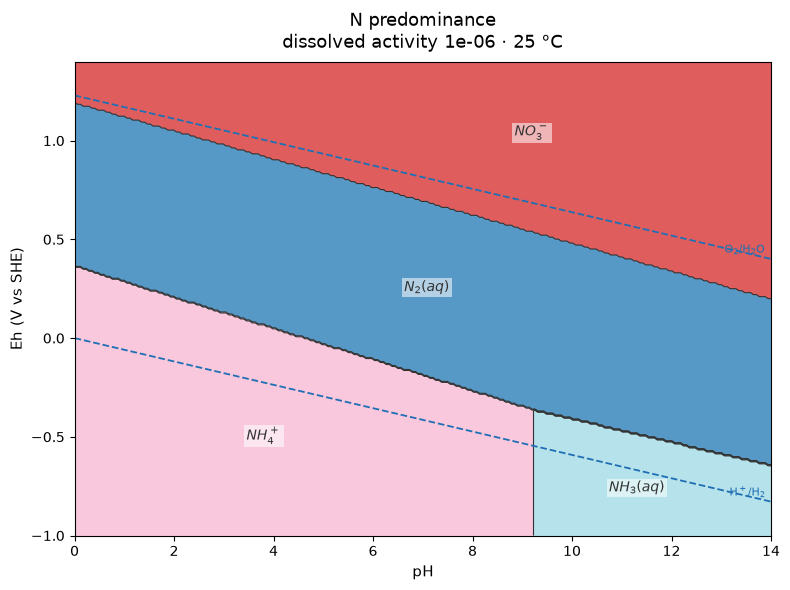

In [8]:
plot_pourbaix("N", figsize=(8.0, 6.0))
plt.show()

Almost the whole diagram is N₂, with nitrate only at the top and ammonium
only at the bottom. Compare that to the real ocean, which is full of nitrate
in the presence of ammonium — two species that this diagram says cannot
coexist. They coexist because the reaction between them is slow without a
catalyst, and **anammox bacteria are that catalyst**: they make a living on
exactly the disequilibrium this figure says should not exist.

## Interactive

In [2]:
from microbial_thermo.figures import interactive_element

interactive_element("N", initial_ph=7.0, initial_log_activity=-5.0)

## Who lives on each step

In [9]:
conditions = mt.Conditions(temperature_c=25.0, pH=7.0)
nitrogen = [
    "ammonia_oxidation",
    "nitrite_oxidation",
    "comammox",
    "denitrification_step_nitrate_nitrite",
    "denitrification_hydrogen",
    "dnra",
    "anammox",
    "n_damo",
    "nitrate_dependent_iron_oxidation",
    "sulfide_oxidation_nitrate",
    "arsenite_oxidation_nitrate",
]
table = mt.energy_table(conditions).set_index("name")
table.loc[nitrogen][["label", "dG per e- (kJ/mol)", "reaction"]]

Duplicate found for species "Fluorphlogopite" in supcrtbl.dat
Duplicate found for species "Arsenic" in supcrtbl.dat
Duplicate found for species "Arsenolite" in supcrtbl.dat


,label,dG per e- (kJ/mol),reaction
name,,,
ammonia_oxidation,Ammonia oxidation (nitritation),-49.111414,1/3 NH4+ + 1/2 O2(aq) -> 1/3 NO2- + 1/3 H2O + ...
nitrite_oxidation,Nitrite oxidation (nitratation),-43.480128,NO2- + 1/2 O2(aq) -> NO3-
comammox,Complete ammonia oxidation (comammox),-47.703593,1/4 NH4+ + 1/2 O2(aq) -> 1/4 NO3- + 1/4 H2O + ...
denitrification_step_nitrate_nitrite,Denitrification step: nitrate to nitrite,-79.244960,H2(g) + NO3- -> NO2- + H2O
denitrification_hydrogen,Denitrification with hydrogen,-110.315989,2/5 H+ + H2(g) + 2/5 NO3- -> 1/5 N2(aq) + 6/5 H2O
dnra,Dissimilatory nitrate reduction to ammonium (D...,-75.021495,1/2 H+ + H2(g) + 1/4 NO3- -> 1/4 NH4+ + 3/4 H2O
anammox,Anaerobic ammonium oxidation (anammox),-114.832669,2/3 NH4+ + 2/3 NO2- -> 2/3 N2(aq) + 4/3 H2O
n_damo,Nitrite-dependent anaerobic methane oxidation ...,-115.675774,1/4 Methane(aq) + 2/3 H+ + 2/3 NO2- -> 1/4 CO2...
nitrate_dependent_iron_oxidation,Nitrate-dependent iron(II) oxidation,-112.911191,2 Fe++ + 14/5 H2O + 2/5 NO3- -> 2 Goethite + 1...


The last four rows are the ones worth dwelling on, because they are all the
same trick: **nitrate and nitrite are good enough oxidants to be worth using
on almost anything.** Methane, ferrous iron, sulfide and arsenite are all
oxidised against them by organisms that do nothing else, and each of those
couplings was discovered long after the nitrogen cycle was supposedly
understood.

`n_damo` is the sharpest example. Methane oxidation against **sulfate**
pays about −3.7 kJ/mol e⁻ — inside the biological energy quantum, a
metabolism that barely exists. Against **nitrite** the same methane pays
−116:

In [10]:
pair = table.loc[["anaerobic_methane_oxidation", "n_damo"]]
pair[["label", "dG per e- (kJ/mol)"]]

,label,dG per e- (kJ/mol)
name,,
anaerobic_methane_oxidation,Anaerobic oxidation of methane with sulfate,-3.687292
n_damo,Nitrite-dependent anaerobic methane oxidation ...,-115.675774


Thirty times the yield, from changing nothing but the acceptor. Both
organisms exist; the AOM consortia are slow, live in consortia, and double
on a timescale of months, while *Methylomirabilis* grows on its own. The
ladder explains both facts at once.

*Methylomirabilis* has a further trick that the thermodynamics cannot see:
it is thought to dismutate NO into N₂ and **O₂**, then use the oxygen in an
ordinary methane monooxygenase — making its own oxidant inside an anoxic
cell. Worth remembering whenever a diagram says a reaction is impossible:
the diagram constrains the overall energy, never the route.

## One thing worth taking away

DNRA and denitrification compete for the same nitrate, and the two diagrams
say different things about them.

Per electron, **denitrification wins outright** — about −110 kJ/mol e⁻
against −75 for DNRA in the table above — and the Frost diagram says why:
the slope from nitrate down to N₂ is +0.729 V, while the slope from nitrate
down to ammonium is only +0.363 V. Ammonium is *not* the deeper point on the
curve at pH 7; N₂ is.

In [11]:
print(f"NO3- to N2   {frost.slope('NO3-', 'N2(aq)'):+.3f} V")
print(f"NO3- to NH4+ {frost.slope('NO3-', 'NH4+'):+.3f} V")

NO3- to N2   +0.729 V
NO3- to NH4+ +0.363 V


So why does DNRA ever happen? Because energy per electron is not what is
scarce in a carbon-rich sediment — **nitrate** is. Denitrification disposes
of five electrons per nitrate; DNRA disposes of eight. When electrons are
abundant and nitrate is not, the pathway that consumes more electrons per
nitrate wins the competition despite paying less for each one.

That is worth keeping in mind whenever a ladder is used to predict what an
ecosystem does: the ladder ranks *yield*, and organisms compete over
whatever is *limiting*. They are the same question only when the limiting
resource is the electron donor.